<a href="https://colab.research.google.com/github/DiyaZahra/fraud_detection_model/blob/main/churn_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Setup
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, classification_report

df = pd.read_csv(r'/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')



In [ ]:
# Initial inspection
print(df.head())
print(df.columns)
print(df.shape)
print(df.describe())
print(df.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df[df['TotalCharges'].isnull()]['tenure'])
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts(normalize=True))


488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


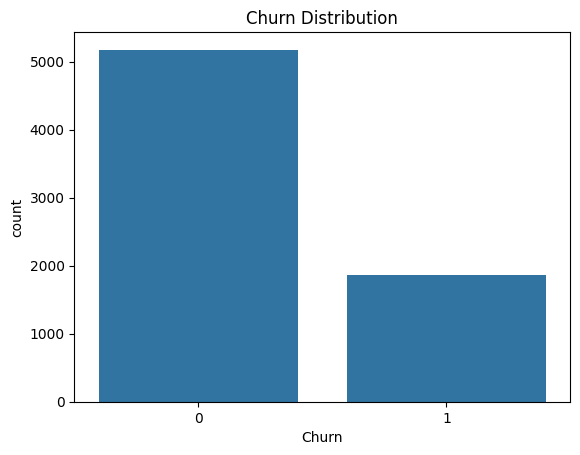

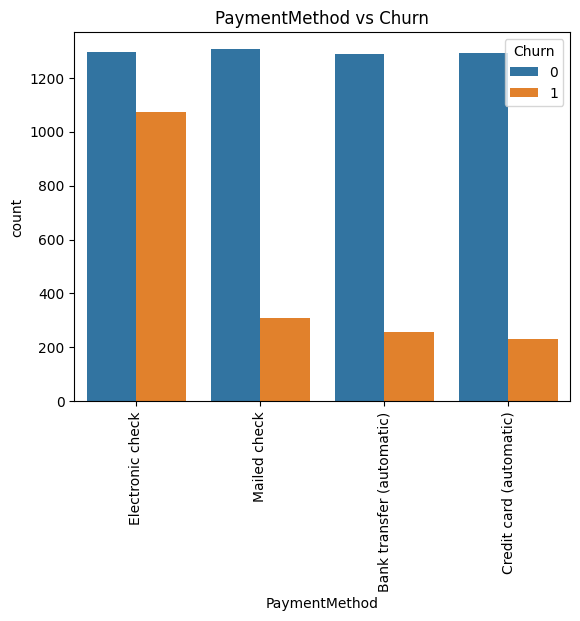

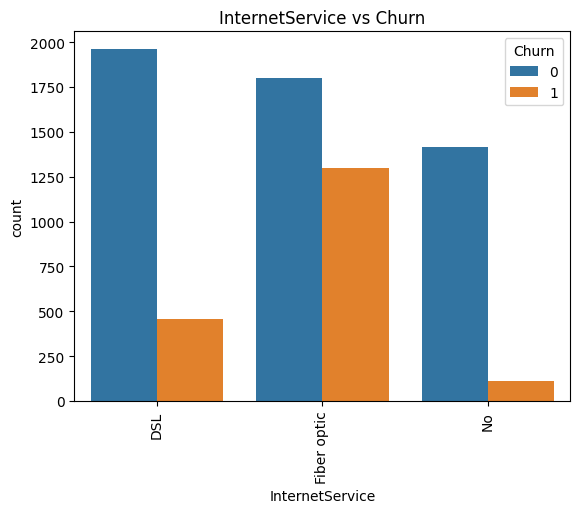

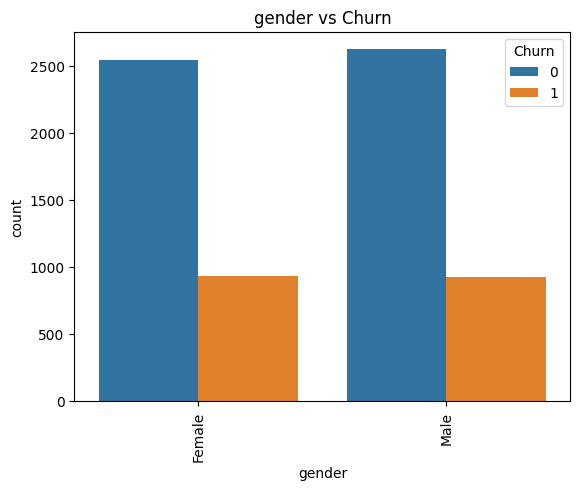

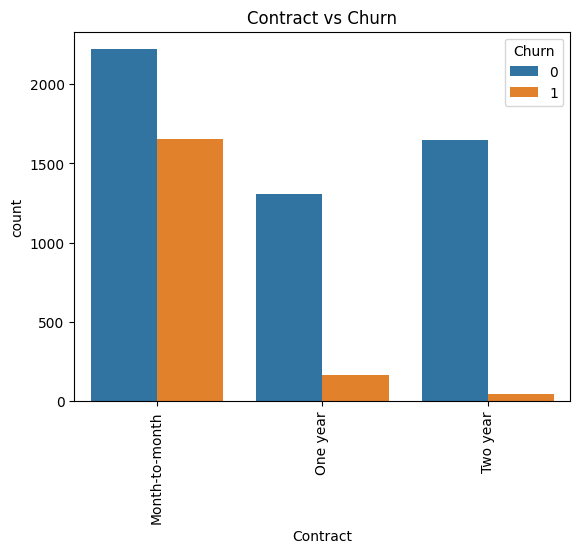

In [ ]:
# EDA / visualization
sns.countplot(x=df['Churn'])
plt.title('Churn Distribution')
plt.show()

cols = ['PaymentMethod', 'InternetService', 'gender', 'Contract']
for col in cols:
    sns.countplot(x=df[col], hue=df['Churn'])
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=90)
    plt.show()

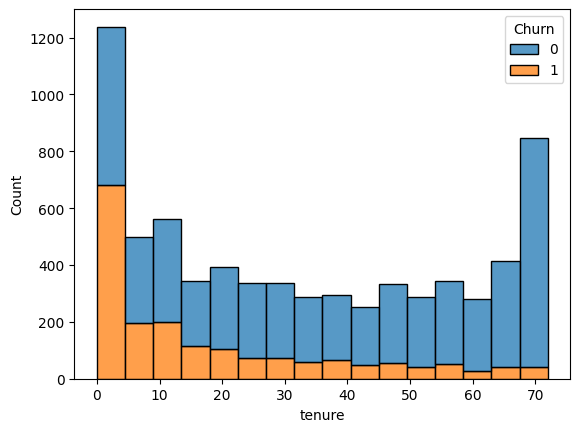

In [ ]:
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.show()

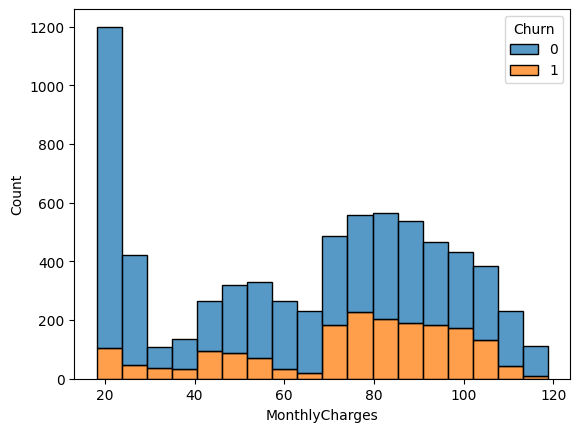

In [ ]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack')
plt.show()

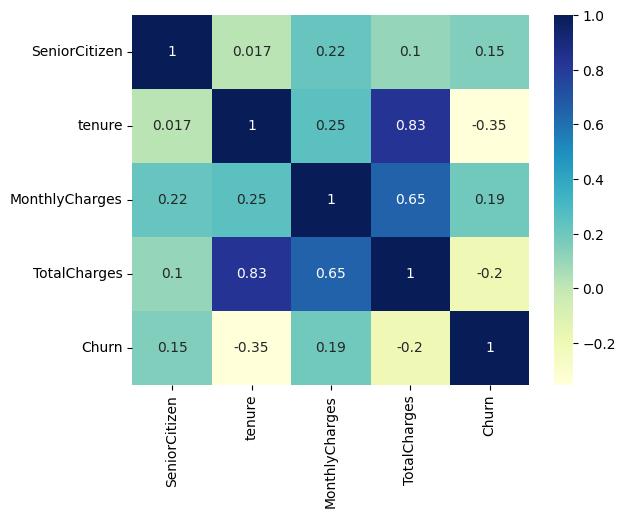

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.show()


In [ ]:
# Feature engineering
df = df.drop('customerID', axis=1)

categorical_columns = df.select_dtypes(include='object').columns
print(categorical_columns)

df = pd.get_dummies(df, columns=[
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
], drop_first=True)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(df.shape)
print(df.dtypes)


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')
(7043, 31)
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurit

In [ ]:
# Train-test split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# Feature scaling
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_test_scaled = standard_scaler.transform(X_test)


In [ ]:
# Decision Tree tuning
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}
grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='f1', n_jobs=-1)
grid_search_dt.fit(X_train_scaled, y_train)
best_model = grid_search_dt.best_estimator_
print("Decision Tree best params:", grid_search_dt.best_params_)
print(classification_report(y_test, best_model.predict(X_test_scaled)))

Decision Tree best params: {'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
# Logistic Regression tuning
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced', None]
}
grid_search_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='f1')
grid_search_lr.fit(X_train_scaled, y_train)
best_model_logistic = grid_search_lr.best_estimator_
print("Logistic Regression best params:", grid_search_lr.best_params_)
print(classification_report(y_test, best_model_logistic.predict(X_test_scaled)))

Logistic Regression best params: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [ ]:
# KNN tuning
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_search_knn.fit(X_train_scaled, y_train)
best_knn_model = grid_search_knn.best_estimator_
print("KNN best params:", grid_search_knn.best_params_)
print(classification_report(y_test, best_knn_model.predict(X_test_scaled)))

KNN best params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1035
           1       0.57      0.56      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



In [ ]:
# Naive Bayes tuning
param_grid_nb = {'var_smoothing': np.logspace(0, -9, num=100)}
grid_search_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, scoring='f1', n_jobs=-1)
grid_search_nb.fit(X_train_scaled, y_train)
best_nb_model = grid_search_nb.best_estimator_
print("Naive Bayes best params:", grid_search_nb.best_params_)
print(classification_report(y_test, best_nb_model.predict(X_test_scaled)))

Naive Bayes best params: {'var_smoothing': np.float64(0.012328467394420659)}
              precision    recall  f1-score   support

           0       0.92      0.58      0.71      1035
           1       0.43      0.87      0.57       374

    accuracy                           0.66      1409
   macro avg       0.67      0.72      0.64      1409
weighted avg       0.79      0.66      0.67      1409



In [ ]:
# Stacking ensemble
stacking_model = StackingClassifier(
    estimators=[
        ('logistic', best_model_logistic),
        ('knn', best_knn_model),
        ('decision_tree_tuned', best_model),
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    cv=5
)
stacking_model.fit(X_train_scaled, y_train)


StackingClassifier(cv=5,
                   estimators=[('logistic',
                                LogisticRegression(C=1, class_weight='balanced',
                                                   max_iter=1000, penalty='l1',
                                                   random_state=42,
                                                   solver='liblinear')),
                               ('knn',
                                KNeighborsClassifier(metric='manhattan',
                                                     n_neighbors=15)),
                               ('decision_tree_tuned',
                                DecisionTreeClassifier(class_weight='balanced',
                                                       max_depth=7,
                                                       random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42))

In [ ]:
# Bagging ensemble
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    n_estimators=50,
    n_jobs=-1,
    random_state=42
)
bagging_model.fit(X_train_scaled, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                   max_depth=5,
                                                   random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:

# Final comparison
models = {
    'logistic_regression': best_model_logistic,
    'knn': best_knn_model,
    'decision_tree_tuned': best_model,
    'naive_bayes': best_nb_model,
    'stacking': stacking_model,
    'bagging': bagging_model,
}

results = []
for model_name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({
        'model_name': model_name,
        'acc': accuracy_score(y_test, y_pred),
        'f1': round(f1_score(y_test, y_pred), 3),
        'recall': round(recall_score(y_test, y_pred), 3),
        'precision': round(precision_score(y_test, y_pred), 3),
    })

results_df = pd.DataFrame(results)
print(results_df)

importances = pd.DataFrame({
    'features' : X.columns,
    'coefficient' : best_model_logistic.coef_[0],
}).sort_values('coefficient',key = abs ,  ascending=False)
print(importances.head(10))



            model_name       acc     f1  recall  precision
0  logistic_regression  0.738112  0.614   0.783      0.504
1                  knn  0.770050  0.563   0.559      0.568
2  decision_tree_tuned  0.738112  0.614   0.786      0.504
3          naive_bayes  0.655784  0.572   0.866      0.427
4             stacking  0.797729  0.605   0.583      0.628
5              bagging  0.746629  0.624   0.791      0.515
                            features  coefficient
1                             tenure    -1.142962
2                     MonthlyCharges    -0.663531
10       InternetService_Fiber optic     0.657939
25                 Contract_Two year    -0.614227
3                       TotalCharges     0.474839
14  OnlineBackup_No internet service    -0.445747
24                 Contract_One year    -0.295392
23               StreamingMovies_Yes     0.225760
21                   StreamingTV_Yes     0.212972
28    PaymentMethod_Electronic check     0.188294


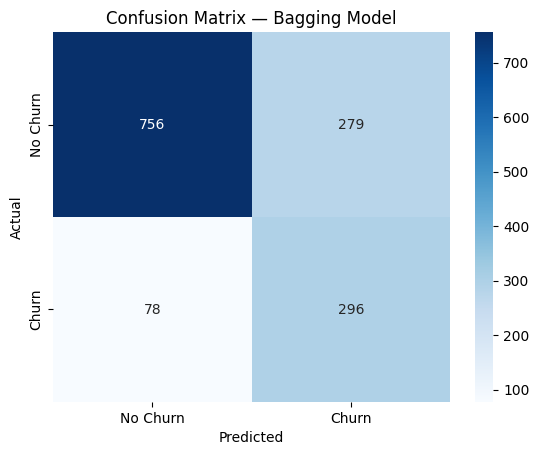

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred_best = bagging_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Bagging Model')
plt.show()
